In [ ]:
#1
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#2
# load dataset : Load CSV dataset into Pandas DataFrame and preview first rows.
import pandas as pd

# load file (change filename if needed)
data = pd.read_csv("/content/drive/MyDrive/Data.csv")

# show first rows
data.head()

/tmp/ipython-input-3046083270.py:6: DtypeWarning: Columns (12,31,32,33,37) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/drive/MyDrive/Data.csv")


,Unnamed: 0,user_id,phq1,phq2,phq3,phq4,phq5,phq6,phq7,phq8,...,q47,happiness,time,period.name,start.time,phq.day,id,Total_Score,Risk_Level,Risk_Number
0,1.0,1.0,3.0,3.0,3.0,3.0,2.0,3.0,1.0,2.0,...,NaN,2.0,2017-01-22 20:11,evening,2017-01-09 7:22,-0.951921,1.0,21.0,Severe,4.0
1,2.0,1.0,3.0,3.0,3.0,3.0,2.0,3.0,1.0,2.0,...,NaN,3.0,2017-02-08 22:53,evening,2017-01-09 7:22,16.159965,1.0,21.0,Severe,4.0
2,3.0,1.0,3.0,3.0,3.0,3.0,2.0,3.0,1.0,2.0,...,NaN,3.0,2017-02-08 8:00,morning,2017-01-09 7:22,15.540289,1.0,21.0,Severe,4.0
3,4.0,1.0,3.0,3.0,3.0,3.0,2.0,3.0,1.0,2.0,...,NaN,2.0,2017-01-22 14:01,midday,2017-01-09 7:22,-1.209259,1.0,21.0,Severe,4.0
4,5.0,1.0,3.0,3.0,3.0,3.0,2.0,3.0,1.0,2.0,...,NaN,2.0,2017-01-21 15:37,midday,2017-01-09 7:22,-2.142604,1.0,21.0,Severe,4.0


In [ ]:
#3
#Selecting Features and Target: This cell prepares the dataset for machine learning by separating input variables (features) and the output variable (target).
# Input features (PHQ answers)
X = data[["phq1","phq2","phq3","phq4","phq5","phq6","phq7","phq8","phq9"]]

# Target (risk level)
y = data["Risk_Number"]

print(X.head())
print(y.head())

   phq1  phq2  phq3  phq4  phq5  phq6  phq7  phq8  phq9
0   3.0   3.0   3.0   3.0   2.0   3.0   1.0   2.0   3.0
1   3.0   3.0   3.0   3.0   2.0   3.0   1.0   2.0   3.0
2   3.0   3.0   3.0   3.0   2.0   3.0   1.0   2.0   3.0
3   3.0   3.0   3.0   3.0   2.0   3.0   1.0   2.0   3.0
4   3.0   3.0   3.0   3.0   2.0   3.0   1.0   2.0   3.0
0    4.0
1    4.0
2    4.0
3    4.0
4    4.0
Name: Risk_Number, dtype: float64


In [ ]:
#4
# STEP 1 — Import Required Libraries
from sklearn.model_selection import train_test_split   # Used to split dataset into training and testing sets
from sklearn.linear_model import LogisticRegression    # Logistic Regression classification model
from sklearn.metrics import accuracy_score, classification_report  # For evaluating model performance
from sklearn.impute import SimpleImputer               # To handle missing values in data
import pandas as pd                                    # Data handling library
import numpy as np                                     # Numerical operations


# STEP 2 — Select Input Features (X) and Target (y)
# X contains PHQ-9 depression symptom scores (input features)
X = data[["phq1","phq2","phq3","phq4","phq5","phq6","phq7","phq8","phq9"]]
# y contains depression risk class (target variable)
y = data["Risk_Number"]


# STEP 3 — Remove Rows where Target is Missing
# (Model cannot train if y has NaN)
data_clean = data.dropna(subset=["Risk_Number"])   # Remove rows where Risk_Number is NaN
# Recreate X and y after cleaning
X = data_clean[["phq1","phq2","phq3","phq4","phq5","phq6","phq7","phq8","phq9"]]
y = data_clean["Risk_Number"]



# STEP 4 — Split Dataset into Train and Test Sets
# 80% training, 20% testing
# stratify=y keeps class distribution balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# STEP 5 — Handle Missing Values in Input Features
# Replace missing values using mean of each column
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)   # Fit imputer on training data and transform
X_test_imputed = imputer.transform(X_test)         # Apply same transformation on test data


# STEP 6 — Train Logistic Regression Model
# class_weight='balanced' helps with imbalanced dataset
model = LogisticRegression(max_iter=1000, class_weight='balanced')
# Train model using training data
model.fit(X_train_imputed, y_train)


# STEP 7 — Predict on Test Data
# Predict depression risk for test dataset
pred = model.predict(X_test_imputed)


# STEP 8 — Evaluate Model Performance
# Accuracy: percentage of correct predictions
print("Accuracy:", accuracy_score(y_test, pred))
# Detailed evaluation: precision, recall, F1-score for each class
print("\nClassification Report:\n")
print(classification_report(y_test, pred))


# STEP 9 — Feature Importance (Which PHQ symptom matters most)
importance = pd.Series(model.coef_[0], index=X.columns)
print("\nFeature Importance (Symptom Impact):\n")
print(importance.sort_values(ascending=False))


# STEP 10 — Predict Risk for a New User (Simulation)
# Example new user PHQ answers
new_user = pd.DataFrame([[2,1,2,3,2,3,2,1,0]], columns=X.columns)
# Apply same imputation
new_user_imputed = imputer.transform(new_user)
# Predict risk
prediction = model.predict(new_user_imputed)

print("\nPredicted Risk for New User:", prediction)

Accuracy: 0.9023152553124009

Classification Report:

              precision    recall  f1-score   support

         2.0       1.00      1.00      1.00         7
         3.0       0.26      0.94      0.40       111
         4.0       1.00      0.90      0.95      3035

    accuracy                           0.90      3153
   macro avg       0.75      0.95      0.78      3153
weighted avg       0.97      0.90      0.93      3153


Feature Importance (Symptom Impact):

phq7    2.097563
phq6    1.535535
phq8    0.428286
phq2    0.416051
phq3   -1.140641
phq4   -2.150549
phq5   -2.349339
phq1   -2.838603
phq9   -3.799213
dtype: float64

Predicted Risk for New User: [4.]


In [ ]:
#5
print(y.value_counts()) #Counts samples in each risk class

Risk_Number
4.0    15173
3.0      557
2.0       34
Name: count, dtype: int64


In [ ]:
#6
print(sorted(y.unique()))   #Shows unique target class values

[np.float64(2.0), np.float64(3.0), np.float64(4.0)]


In [ ]:
#7
print(pred[:20])   #Displays first 20 predicted labels


[4. 4. 4. 3. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]


In [ ]:
#8
#Shows precision, recall, F1 performance
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         2.0       1.00      1.00      1.00         7
         3.0       0.26      0.94      0.40       111
         4.0       1.00      0.90      0.95      3035

    accuracy                           0.90      3153
   macro avg       0.75      0.95      0.78      3153
weighted avg       0.97      0.90      0.93      3153



In [ ]:
#9
#Trains balanced model, prints performance report
model = LogisticRegression(max_iter=1000, class_weight='balanced')  # Creates balanced Logistic Regression model
model.fit(X_train_imputed, y_train)                                 # Trains model using training data
# Recalculate predictions with the new model for evaluation if needed
pred_cleaned = model.predict(X_test_imputed)                        # Predicts classes for test data
print(classification_report(y_test, pred_cleaned))                  # Shows precision, recall, F1 metrics

              precision    recall  f1-score   support

         2.0       1.00      1.00      1.00         7
         3.0       0.26      0.94      0.40       111
         4.0       1.00      0.90      0.95      3035

    accuracy                           0.90      3153
   macro avg       0.75      0.95      0.78      3153
weighted avg       0.97      0.90      0.93      3153



In [ ]:
#10
import pandas as pd    # Imports pandas library for analysis

importance = pd.Series(model.coef_[0], index=X.columns)   # Creates feature importance from coefficients
importance.sort_values(ascending=False)     # Sorts features by highest importance
# 👉 Concentration (phq7) 👉 Worthlessness (phq6) 👉 Restlessness (phq8)

,0
phq7,2.097563
phq6,1.535535
phq8,0.428286
phq2,0.416051
phq3,-1.140641
phq4,-2.150549
phq5,-2.349339
phq1,-2.838603
phq9,-3.799213


In [ ]:
#11
#predict for a new user
new_user = pd.DataFrame([[2,1,2,3,1,2,2,1,0]], columns=X.columns)  # Creates new user PHQ input
new_user_imputed = imputer.transform(new_user)     # Applies same missing value handling
prediction = model.predict(new_user_imputed)       # Predicts risk for new user
print("Predicted Risk:", prediction)               # Displays predicted depression risk


Predicted Risk: [4.]


In [ ]:
#12
#add nlp mood detection
from textblob import TextBlob   #Imports TextBlob for sentiment analysis

text = "I feel happy"    # Stores user mood text
sentiment = TextBlob(text).sentiment.polarity    # Calculates sentiment polarity score
print(sentiment)     # Displays emotion sentiment value

0.8


,Total_Score
user_id,
1.0,"Axes(0.125,0.11;0.775x0.77)"
2.0,"Axes(0.125,0.11;0.775x0.77)"
3.0,"Axes(0.125,0.11;0.775x0.77)"
4.0,"Axes(0.125,0.11;0.775x0.77)"
5.0,"Axes(0.125,0.11;0.775x0.77)"
...,...
181.0,"Axes(0.125,0.11;0.775x0.77)"
182.0,"Axes(0.125,0.11;0.775x0.77)"
183.0,"Axes(0.125,0.11;0.775x0.77)"


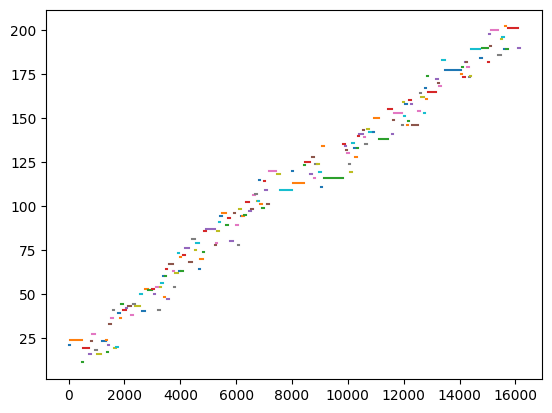

In [ ]:
#13
data.groupby("user_id")["Total_Score"].plot()   #Plots depression trend per user

In [ ]:
#14
# You already have:  Final Risk = (prediction → ML Risk (0–4)) + (sentiment → NLP score (−1 to +1))
# Convert prediction to integer
ml_risk = int(prediction[0])

# Emotion adjustment logic
if sentiment <= -0.5:
    adjusted_risk = min(ml_risk + 1, 4)   # Increase risk (max 4)
elif sentiment >= 0.5:
    adjusted_risk = max(ml_risk - 1, 0)   # Decrease risk (min 0)
else:
    adjusted_risk = ml_risk               # Keep same

print("ML Risk:", ml_risk)
print("Sentiment Score:", sentiment)
print("Final Adjusted Risk:", adjusted_risk)

ML Risk: 4
Sentiment Score: -0.25
Final Adjusted Risk: 4
